# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [1]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [2]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


2026-04-23 22:25:00.655016: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-23 22:25:00.656569: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-23 22:25:00.681061: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-23 22:25:00.681088: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-23 22:25:00.681105: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [3]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [4]:
def load_har_data(root_dir="UCI HAR Dataset"):
    root_dir = pathlib.Path(root_dir)
    X_train = np.loadtxt(root_dir / "train" / "X_train.txt", dtype=np.float32)
    y_train = np.loadtxt(root_dir / "train" / "y_train.txt", dtype=np.int32) - 1
    X_test = np.loadtxt(root_dir / "test" / "X_test.txt", dtype=np.float32)
    y_test = np.loadtxt(root_dir / "test" / "y_test.txt", dtype=np.int32) - 1
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Number of features:", num_features)
print("Number of classes :", num_classes)


X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape : (2947, 561)
y_test shape : (2947,)
Number of features: 561
Number of classes : 6


## 5. Quick Inspection


In [5]:
label_counts = pd.Series(y_train).value_counts().sort_index()
summary_df = pd.DataFrame({
    "Class Index": np.arange(num_classes),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})
summary_df


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [6]:
def build_baseline_model(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/40
92/92 [==============================] - 1s 6ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 3ms/step - loss: 0.1640 - accuracy: 0.9367 - val_loss: 0.1402 - val_accuracy: 0.9381
Epoch 3/40
92/92 [==============================] - 1s 6ms/step - loss: 0.1165 - accuracy: 0.9561 - val_loss: 0.2180 - val_accuracy: 0.9259
Epoch 4/40
92/92 [==============================] - 1s 6ms/step - loss: 0.0886 - accuracy: 0.9641 - val_loss: 0.1500 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0885 - accuracy: 0.9645 - val_loss: 0.2037 - val_accuracy: 0.9218
Epoch 6/40
92/92 [==============================] - 1s 7ms/step - loss: 0.0748 - accuracy: 0.9711 - val_loss: 0.2056 - val_accuracy: 0.9313
Epoch 7/40
92/92 [==============================] - 0s 5ms/step - loss: 0.0765 - accuracy: 0.9716 - val_loss: 0.1482 - val_accuracy: 0.9443
Epoch 8/40
92/92 [==

### Training Curves


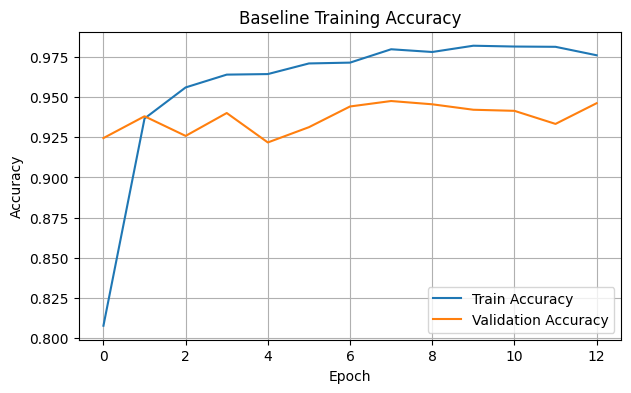

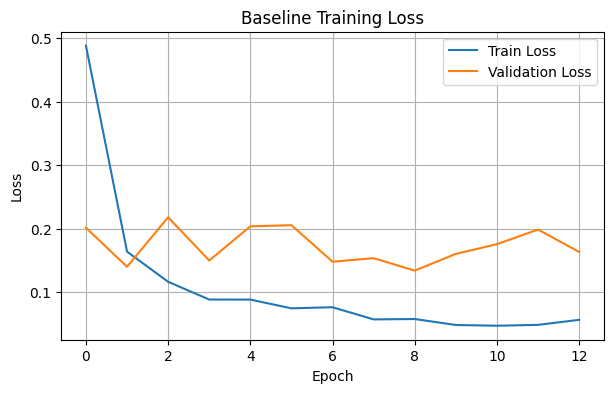

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline Training Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Training Loss")
plt.legend()
plt.grid(True)
plt.show()


## 7. Evaluate the Baseline Keras Model


93/93 [==============================] - 0s 1ms/step
Baseline Keras Test Accuracy: 0.9220
                    precision    recall  f1-score   support

           WALKING       0.95      0.94      0.94       496
  WALKING_UPSTAIRS       0.95      0.90      0.92       471
WALKING_DOWNSTAIRS       0.89      0.95      0.92       420
           SITTING       0.98      0.80      0.88       491
          STANDING       0.81      0.98      0.89       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.92      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.92      0.92      2947



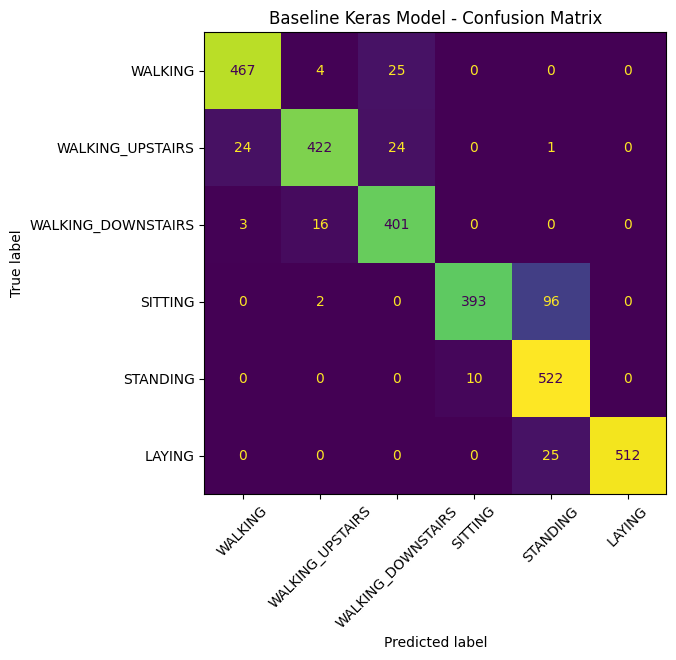

In [9]:
baseline_probs = baseline_model.predict(X_test)
baseline_preds = np.argmax(baseline_probs, axis=1)
baseline_acc = accuracy_score(y_test, baseline_preds)

print(f"Baseline Keras Test Accuracy: {baseline_acc:.4f}")
print(classification_report(y_test, baseline_preds, target_names=class_names))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, baseline_preds),
    display_labels=class_names,
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Baseline Keras Model - Confusion Matrix")
plt.show()


## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [10]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    for i in range(min(300, len(X_train))):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point)
            x = np.clip(x, -128, 127).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point)
            x = np.clip(x, 0, 255).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()


## 9. Post-Training Quantization (PTQ)


In [11]:
fp32_tflite = convert_to_tflite_fp32(baseline_model)
dynamic_tflite = convert_to_tflite_dynamic_range(baseline_model)
float16_tflite = convert_to_tflite_float16(baseline_model)
int8_tflite = convert_to_tflite_int8(baseline_model)

fp32_size_kb = save_binary_model(fp32_tflite, "baseline_fp32.tflite")
dynamic_size_kb = save_binary_model(dynamic_tflite, "baseline_dynamic_range.tflite")
float16_size_kb = save_binary_model(float16_tflite, "baseline_float16.tflite")
int8_size_kb = save_binary_model(int8_tflite, "baseline_int8.tflite")

fp32_acc, fp32_preds = evaluate_tflite_model(fp32_tflite, X_test, y_test)
dynamic_acc, dynamic_preds = evaluate_tflite_model(dynamic_tflite, X_test, y_test)
float16_acc, float16_preds = evaluate_tflite_model(float16_tflite, X_test, y_test)
int8_acc, int8_preds = evaluate_tflite_model(int8_tflite, X_test, y_test)

print(f"FP32 TFLite Accuracy: {fp32_acc:.4f}, Size: {fp32_size_kb:.2f} KB")
print(f"Dynamic Range Accuracy: {dynamic_acc:.4f}, Size: {dynamic_size_kb:.2f} KB")
print(f"Float16 Accuracy: {float16_acc:.4f}, Size: {float16_size_kb:.2f} KB")
print(f"Int8 Accuracy: {int8_acc:.4f}, Size: {int8_size_kb:.2f} KB")


INFO:tensorflow:Assets written to: /tmp/tmp8fpik9yt/assets


INFO:tensorflow:Assets written to: /tmp/tmp8fpik9yt/assets
2026-04-23 22:25:12.705694: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 22:25:12.705735: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 22:25:12.705914: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp8fpik9yt
2026-04-23 22:25:12.706456: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 22:25:12.706466: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp8fpik9yt
2026-04-23 22:25:12.708909: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-23 22:25:12.709484: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 22:25:12.738546: I tensorflow/cc/saved_model/loader.cc:217] Running initializatio

INFO:tensorflow:Assets written to: /tmp/tmpht678qxw/assets


INFO:tensorflow:Assets written to: /tmp/tmpht678qxw/assets
2026-04-23 22:25:13.082902: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 22:25:13.082946: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 22:25:13.083055: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpht678qxw
2026-04-23 22:25:13.083636: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 22:25:13.083647: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpht678qxw
2026-04-23 22:25:13.085554: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 22:25:13.110298: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpht678qxw
2026-04-23 22:25:13.116497: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmp04h_8a9e/assets


INFO:tensorflow:Assets written to: /tmp/tmp04h_8a9e/assets
2026-04-23 22:25:13.520782: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 22:25:13.520824: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 22:25:13.520928: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp04h_8a9e
2026-04-23 22:25:13.521542: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 22:25:13.521551: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp04h_8a9e
2026-04-23 22:25:13.523606: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 22:25:13.552229: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp04h_8a9e
2026-04-23 22:25:13.559005: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpqi0bxhnp/assets


INFO:tensorflow:Assets written to: /tmp/tmpqi0bxhnp/assets
/home/chetanm/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 22:25:13.910896: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 22:25:13.910951: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 22:25:13.911110: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpqi0bxhnp
2026-04-23 22:25:13.911912: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 22:25:13.911932: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpqi0bxhnp
2026-04-23 22:25:13.915308: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2

FP32 TFLite Accuracy: 0.9220, Size: 726.72 KB
Dynamic Range Accuracy: 0.9213, Size: 186.11 KB
Float16 Accuracy: 0.9220, Size: 365.71 KB
Int8 Accuracy: 0.9220, Size: 185.34 KB


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 10. PTQ Comparison: Accuracy and Model Size


In [12]:
ptq_results = pd.DataFrame([
    ["Baseline DNN", "Keras FP32", baseline_acc, np.nan],
    ["Baseline DNN", "TFLite FP32", fp32_acc, fp32_size_kb],
    ["Baseline DNN", "TFLite Dynamic Range", dynamic_acc, dynamic_size_kb],
    ["Baseline DNN", "TFLite Float16", float16_acc, float16_size_kb],
    ["Baseline DNN", "TFLite Int8", int8_acc, int8_size_kb],
], columns=["Model Family", "Format", "Test Accuracy", "Model Size (KB)"])
ptq_results


,Model Family,Format,Test Accuracy,Model Size (KB)
0,Baseline DNN,Keras FP32,0.921955,NaN
1,Baseline DNN,TFLite FP32,0.921955,726.718750
2,Baseline DNN,TFLite Dynamic Range,0.921276,186.109375
3,Baseline DNN,TFLite Float16,0.921955,365.710938
4,Baseline DNN,TFLite Int8,0.921955,185.335938


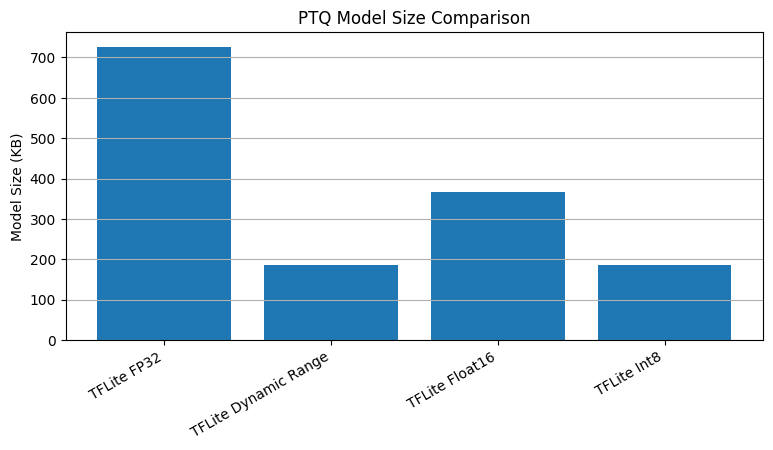

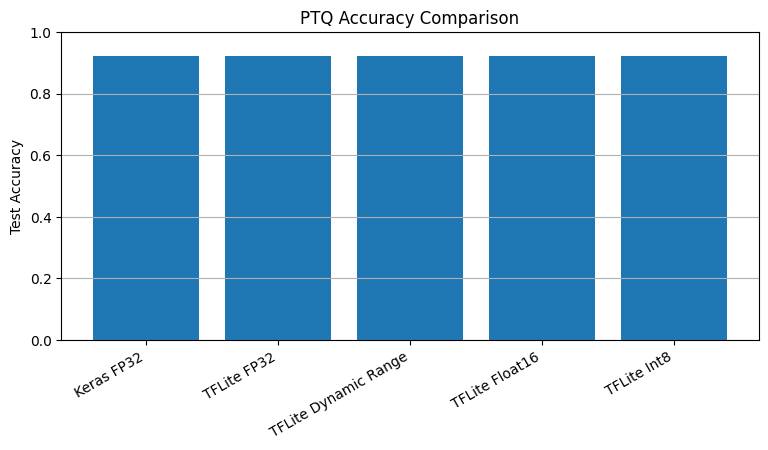

In [13]:
plot_df = ptq_results.dropna(subset=["Model Size (KB)"])

plt.figure(figsize=(9, 4))
plt.bar(plot_df["Format"], plot_df["Model Size (KB)"])
plt.ylabel("Model Size (KB)")
plt.title("PTQ Model Size Comparison")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(9, 4))
plt.bar(ptq_results["Format"], ptq_results["Test Accuracy"])
plt.ylabel("Test Accuracy")
plt.title("PTQ Accuracy Comparison")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.0)
plt.grid(axis="y")
plt.show()


### Confusion Matrix for the PTQ Int8 Model


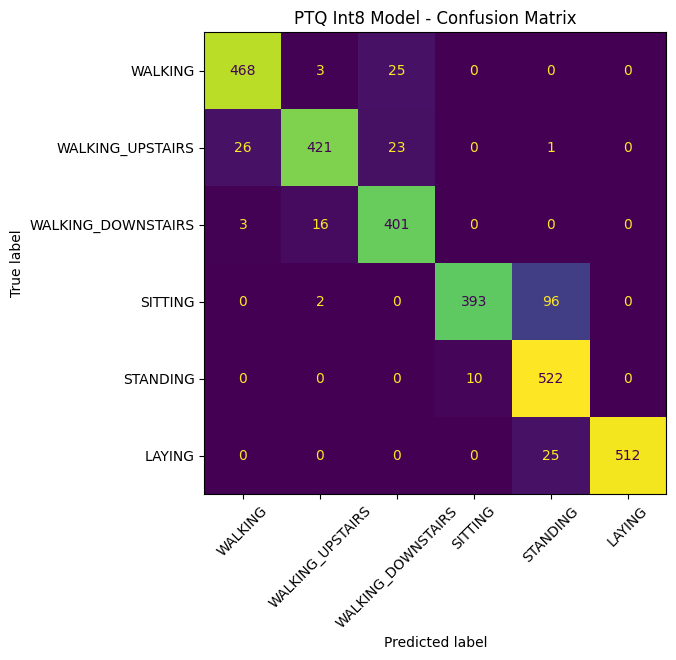

                    precision    recall  f1-score   support

           WALKING       0.94      0.94      0.94       496
  WALKING_UPSTAIRS       0.95      0.89      0.92       471
WALKING_DOWNSTAIRS       0.89      0.95      0.92       420
           SITTING       0.98      0.80      0.88       491
          STANDING       0.81      0.98      0.89       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.92      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.92      0.92      2947



In [14]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, int8_preds),
    display_labels=class_names,
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("PTQ Int8 Model - Confusion Matrix")
plt.show()

print(classification_report(y_test, int8_preds, target_names=class_names))


## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [15]:
quantize_model = tfmot.quantization.keras.quantize_model
qat_model = quantize_model(baseline_model)

qat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
qat_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quantize_layer (QuantizeLa  (None, 561)               3         
 yer)                                                            
                                                                 
 quant_dense (QuantizeWrapp  (None, 256)               143877    
 erV2)                                                           
                                                                 
 quant_dense_1 (QuantizeWra  (None, 128)               32901     
 pperV2)                                                         
                                                                 
 quant_dense_2 (QuantizeWra  (None, 64)                8261      
 pperV2)                                                         
                                                                 
 quant_dense_3 (QuantizeWra  (None, 6)                 3

### Fine-Tune the QAT Model


In [16]:
qat_history = qat_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64,
    verbose=1,
)


Epoch 1/8
92/92 [==============================] - 1s 5ms/step - loss: 0.0453 - accuracy: 0.9850 - val_loss: 0.1297 - val_accuracy: 0.9449
Epoch 2/8
92/92 [==============================] - 0s 4ms/step - loss: 0.0365 - accuracy: 0.9888 - val_loss: 0.1328 - val_accuracy: 0.9483
Epoch 3/8
92/92 [==============================] - 0s 4ms/step - loss: 0.0363 - accuracy: 0.9874 - val_loss: 0.1416 - val_accuracy: 0.9477
Epoch 4/8
92/92 [==============================] - 1s 6ms/step - loss: 0.0327 - accuracy: 0.9884 - val_loss: 0.1319 - val_accuracy: 0.9456
Epoch 5/8
92/92 [==============================] - 1s 6ms/step - loss: 0.0318 - accuracy: 0.9893 - val_loss: 0.1688 - val_accuracy: 0.9422
Epoch 6/8
92/92 [==============================] - 2s 19ms/step - loss: 0.0316 - accuracy: 0.9884 - val_loss: 0.1545 - val_accuracy: 0.9463
Epoch 7/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0315 - accuracy: 0.9895 - val_loss: 0.1364 - val_accuracy: 0.9483
Epoch 8/8
92/92 [=========

### Evaluate the QAT Keras Model


In [17]:
qat_probs = qat_model.predict(X_test)
qat_preds = np.argmax(qat_probs, axis=1)
qat_acc = accuracy_score(y_test, qat_preds)

print(f"QAT Keras Test Accuracy: {qat_acc:.4f}")
print(classification_report(y_test, qat_preds, target_names=class_names))


93/93 [==============================] - 0s 1ms/step
QAT Keras Test Accuracy: 0.9321
                    precision    recall  f1-score   support

           WALKING       0.92      0.97      0.95       496
  WALKING_UPSTAIRS       0.94      0.90      0.92       471
WALKING_DOWNSTAIRS       0.94      0.94      0.94       420
           SITTING       0.97      0.85      0.91       491
          STANDING       0.84      0.98      0.90       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.93      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.93      0.93      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [18]:
qat_int8_tflite = convert_to_tflite_int8(qat_model)
qat_int8_size_kb = save_binary_model(qat_int8_tflite, "qat_int8.tflite")
qat_int8_acc, qat_int8_preds = evaluate_tflite_model(qat_int8_tflite, X_test, y_test)

print(f"QAT Int8 TFLite Accuracy: {qat_int8_acc:.4f}")
print(f"QAT Int8 TFLite Size: {qat_int8_size_kb:.2f} KB")


INFO:tensorflow:Assets written to: /tmp/tmp_7mjhi6x/assets


INFO:tensorflow:Assets written to: /tmp/tmp_7mjhi6x/assets


QAT Int8 TFLite Accuracy: 0.9318
QAT Int8 TFLite Size: 185.70 KB


/home/chetanm/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 22:25:21.929435: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 22:25:21.929474: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 22:25:21.929572: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp_7mjhi6x
2026-04-23 22:25:21.930976: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 22:25:21.930987: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp_7mjhi6x
2026-04-23 22:25:21.935979: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 22:25:21.974521: I tensorflow/cc/saved_model/load

## 12. PTQ Int8 vs QAT Int8


In [19]:
qat_vs_ptq_results = pd.DataFrame([
    ["PTQ Int8", int8_acc, int8_size_kb],
    ["QAT Int8", qat_int8_acc, qat_int8_size_kb],
], columns=["Model", "Test Accuracy", "Model Size (KB)"])
qat_vs_ptq_results


,Model,Test Accuracy,Model Size (KB)
0,PTQ Int8,0.921955,185.335938
1,QAT Int8,0.931795,185.695312


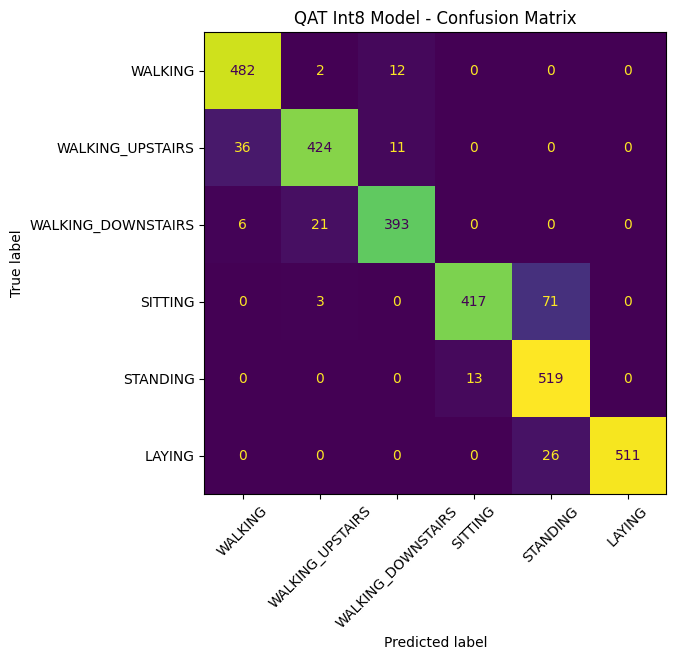

In [20]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, qat_int8_preds),
    display_labels=class_names,
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("QAT Int8 Model - Confusion Matrix")
plt.show()


## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
   INT8
3. Which quantization method gave the best accuracy among the TensorFlow Lite models?
   FP32 & Float 16
5. Did QAT improve the final int8 model compared with PTQ int8?
   Not significantly
7. Why is this dataset a good fit for a DNN-based TinyML workflow?
   Data is small and low dimensional
9. If you were deploying this model on a resource-constrained device, which version would you choose and why?
    Int8 as it has the smallest size


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
